### **Load & Explore**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('titanic.csv')
print("Shape:", df.shape)
print("\nHead:\n", df.head())
print("\nInfo:")
df.info()
print("\nDescribe:\n", df.describe())
print("\nNull Values:\n", df.isnull().sum())

Shape: (891, 12)

Head:
    PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8

### **Handle Missing Values**

In [2]:
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
df.drop(columns=['Cabin'], inplace=True)

print("Nulls after cleaning:\n", df.isnull().sum())
print("\nShape after cleaning:", df.shape)

print("\nSurvival Count:\n",   df['Survived'].value_counts())
print("\nGender Count:\n",     df['Sex'].value_counts())
print("\nPclass Count:\n",     df['Pclass'].value_counts())
print("\nEmbarked Count:\n",   df['Embarked'].value_counts())

Nulls after cleaning:
 PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

Shape after cleaning: (891, 11)

Survival Count:
 Survived
0    549
1    342
Name: count, dtype: int64

Gender Count:
 Sex
male      577
female    314
Name: count, dtype: int64

Pclass Count:
 Pclass
3    491
1    216
2    184
Name: count, dtype: int64

Embarked Count:
 Embarked
S    646
C    168
Q     77
Name: count, dtype: int64


C:\Users\Star\AppData\Local\Temp\ipykernel_5368\3108344606.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
C:\Users\Star\AppData\Local\Temp\ipykernel_5368\3108344606.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For examp

### **Survival Plots**

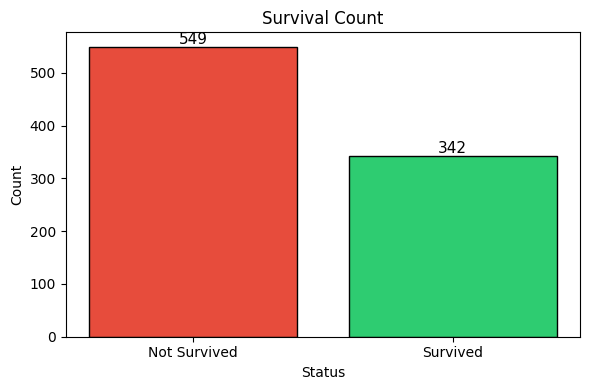

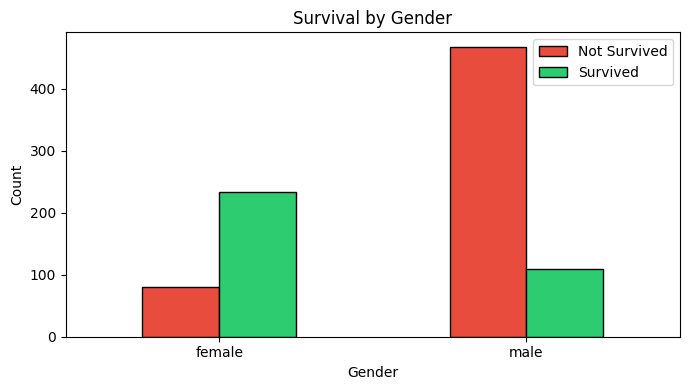

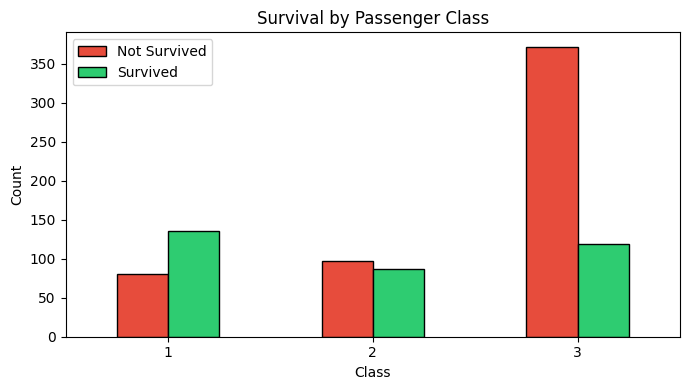

In [3]:
# Survival Count
survival_counts = df['Survived'].value_counts()
plt.figure(figsize=(6,4))
bars = plt.bar(['Not Survived','Survived'], survival_counts,
               color=['#e74c3c','#2ecc71'], edgecolor='black')
plt.title('Survival Count')
plt.xlabel('Status')
plt.ylabel('Count')
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 5,
             str(int(bar.get_height())),
             ha='center', fontsize=11)
plt.tight_layout()
plt.show()

# Survival by Gender
gender_survival = df.groupby('Sex')['Survived'].value_counts().unstack()
gender_survival.plot(kind='bar', color=['#e74c3c','#2ecc71'],
                     figsize=(7,4), edgecolor='black')
plt.title('Survival by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(['Not Survived','Survived'])
plt.tight_layout()
plt.show()

# Survival by Pclass
pclass_survival = df.groupby('Pclass')['Survived'].value_counts().unstack()
pclass_survival.plot(kind='bar', color=['#e74c3c','#2ecc71'],
                     figsize=(7,4), edgecolor='black')
plt.title('Survival by Passenger Class')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(['Not Survived','Survived'])
plt.tight_layout()
plt.show()

### **Distribution Plots**

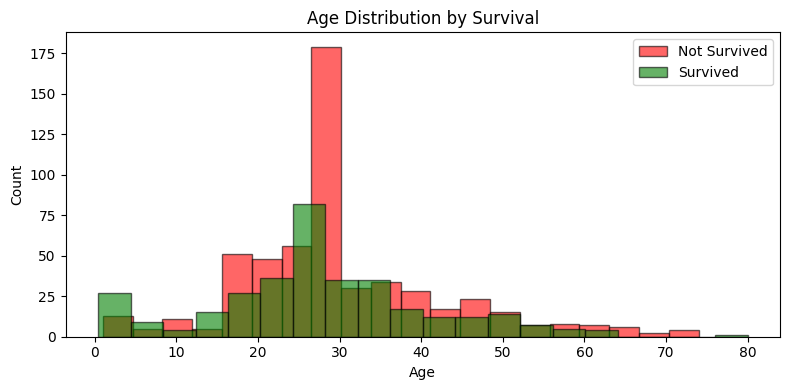

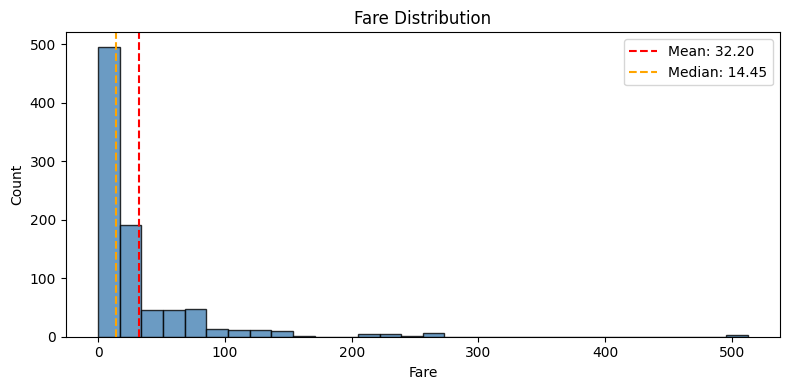

C:\Users\Star\AppData\Local\Temp\ipykernel_5368\2047063333.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([pclass1, pclass2, pclass3],


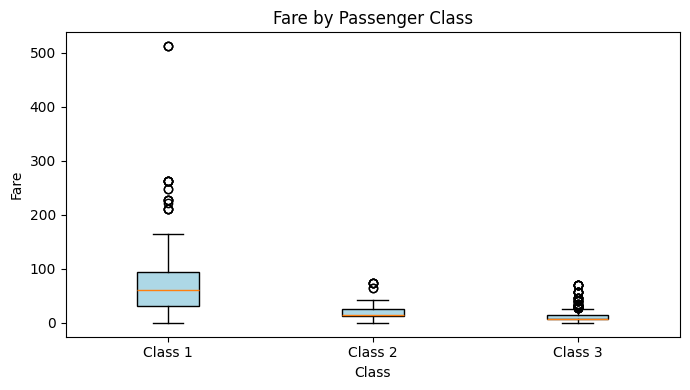

In [4]:
# Age Distribution
plt.figure(figsize=(8,4))
plt.hist(df[df['Survived']==0]['Age'], bins=20, alpha=0.6,
         color='red', edgecolor='black', label='Not Survived')
plt.hist(df[df['Survived']==1]['Age'], bins=20, alpha=0.6,
         color='green', edgecolor='black', label='Survived')
plt.title('Age Distribution by Survival')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

# Fare Distribution
plt.figure(figsize=(8,4))
plt.hist(df['Fare'], bins=30, color='steelblue', edgecolor='black', alpha=0.8)
plt.title('Fare Distribution')
plt.xlabel('Fare')
plt.ylabel('Count')
plt.axvline(df['Fare'].mean(), color='red', linestyle='--',
            label=f'Mean: {df["Fare"].mean():.2f}')
plt.axvline(df['Fare'].median(), color='orange', linestyle='--',
            label=f'Median: {df["Fare"].median():.2f}')
plt.legend()
plt.tight_layout()
plt.show()

# Pclass vs Fare Boxplot
pclass1 = df[df['Pclass']==1]['Fare']
pclass2 = df[df['Pclass']==2]['Fare']
pclass3 = df[df['Pclass']==3]['Fare']
plt.figure(figsize=(7,4))
plt.boxplot([pclass1, pclass2, pclass3],
            labels=['Class 1','Class 2','Class 3'],
            patch_artist=True,
            boxprops=dict(facecolor='lightblue'))
plt.title('Fare by Passenger Class')
plt.xlabel('Class')
plt.ylabel('Fare')
plt.tight_layout()
plt.show()

### **Extra Plots & Conclusions**

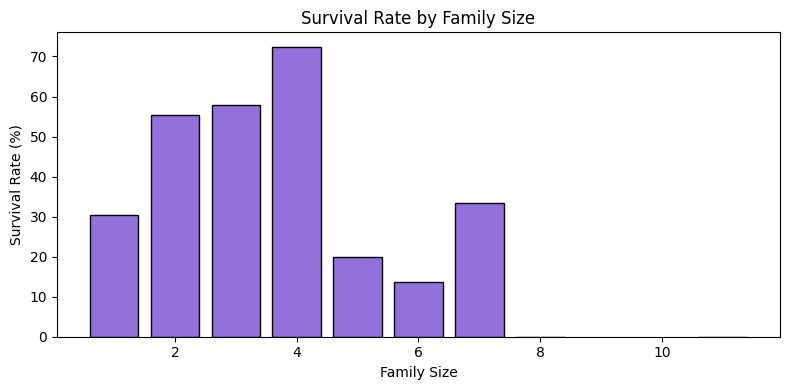

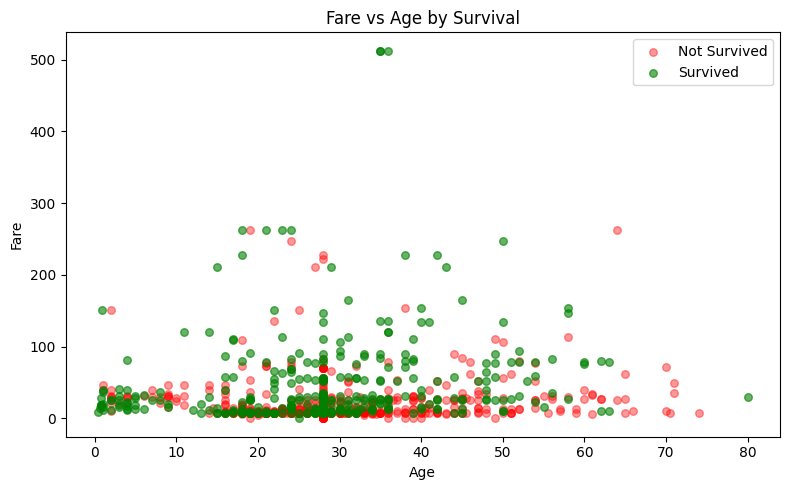

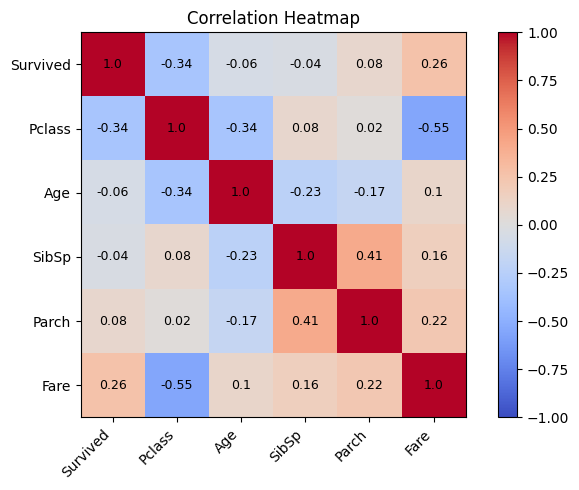

     TITANIC EDA - KEY FINDINGS
Total Passengers : 891
Survived         : 342 (38.4%)
Not Survived     : 549 (61.6%)

Female Survival  : 74.2%
Male Survival    : 18.9%

Class 1 Survival : 63.0%
Class 2 Survival : 47.3%
Class 3 Survival : 24.2%

Avg Age          : 29.4 years
Avg Fare         : £32.20


In [6]:
# Family Size vs Survival
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
family_survival  = df.groupby('FamilySize')['Survived'].mean() * 100
plt.figure(figsize=(8,4))
plt.bar(family_survival.index, family_survival.values,
        color='mediumpurple', edgecolor='black')
plt.title('Survival Rate by Family Size')
plt.xlabel('Family Size')
plt.ylabel('Survival Rate (%)')
plt.tight_layout()
plt.show()

# Fare vs Age Scatter by Survival
survived     = df[df['Survived']==1]
not_survived = df[df['Survived']==0]
plt.figure(figsize=(8,5))
plt.scatter(not_survived['Age'], not_survived['Fare'],
            color='red', alpha=0.4, label='Not Survived', s=30)
plt.scatter(survived['Age'], survived['Fare'],
            color='green', alpha=0.6, label='Survived', s=30)
plt.title('Fare vs Age by Survival')
plt.xlabel('Age')
plt.ylabel('Fare')
plt.legend()
plt.tight_layout()
plt.show()

# Correlation Heatmap
num_cols = ['Survived','Pclass','Age','SibSp','Parch','Fare']
corr = df[num_cols].corr().round(2)
fig, ax = plt.subplots(figsize=(7,5))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im)
ax.set_xticks(range(len(num_cols)))
ax.set_yticks(range(len(num_cols)))
ax.set_xticklabels(num_cols, rotation=45, ha='right')
ax.set_yticklabels(num_cols)
for i in range(len(corr)):
    for j in range(len(corr.columns)):
        ax.text(j, i, corr.iloc[i,j], ha='center', va='center', fontsize=9)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

# Conclusions
print("=" * 45)
print("     TITANIC EDA - KEY FINDINGS")
print("=" * 45)
print(f"Total Passengers : {len(df)}")
print(f"Survived         : {df['Survived'].sum()} ({df['Survived'].mean()*100:.1f}%)")
print(f"Not Survived     : {(df['Survived']==0).sum()} ({(df['Survived']==0).mean()*100:.1f}%)")
print(f"\nFemale Survival  : {df[df['Sex']=='female']['Survived'].mean()*100:.1f}%")
print(f"Male Survival    : {df[df['Sex']=='male']['Survived'].mean()*100:.1f}%")
print(f"\nClass 1 Survival : {df[df['Pclass']==1]['Survived'].mean()*100:.1f}%")
print(f"Class 2 Survival : {df[df['Pclass']==2]['Survived'].mean()*100:.1f}%")
print(f"Class 3 Survival : {df[df['Pclass']==3]['Survived'].mean()*100:.1f}%")
print(f"\nAvg Age          : {df['Age'].mean():.1f} years")
print(f"Avg Fare         : £{df['Fare'].mean():.2f}")
print("=" * 45)